In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import transforms

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [3]:
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

In [4]:
len(train_dataset)
len(test_dataset)

60000

10000

In [5]:
img, label = train_dataset[0]
img.shape
label

torch.Size([1, 28, 28])

5

In [6]:
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False,
                         num_workers=0, pin_memory=False)

In [7]:
len(train_loader)
len(test_loader)

1875

313

In [8]:
for batch in train_loader:
  images, labels = batch
  images.shape
  labels.shape
  break

torch.Size([32, 1, 28, 28])

torch.Size([32])

In [9]:
images, labels = next(iter(train_loader))
images.shape
labels.shape

torch.Size([32, 1, 28, 28])

torch.Size([32])

tensor(5)

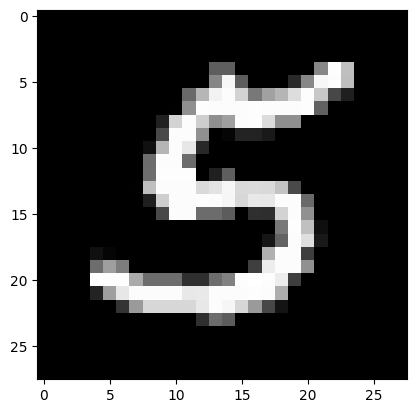

In [10]:
_ = plt.imshow(images[0, 0], cmap='gray')
labels[0]

# MLP 

In [11]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

In [12]:
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()

    self.fc1 = nn.Linear(784, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 10)
    self.dropout = nn.Dropout(0.20)

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = F.relu(self.fc1(x))
    x = self.dropout(x)

    x = F.relu(self.fc2(x))
    x = self.dropout(x)

    return self.fc3(x)

In [13]:
model = MLP()

total = 0
for name, param in model.named_parameters():
  total += param.numel()
  print(name, param.shape)

print(f'total params: {total}')

fc1.weight torch.Size([128, 784])
fc1.bias torch.Size([128])
fc2.weight torch.Size([64, 128])
fc2.bias torch.Size([64])
fc3.weight torch.Size([10, 64])
fc3.bias torch.Size([10])
total params: 109386


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.0001)

In [15]:
logits = torch.tensor([10, 0, 0], dtype=float)  # last layer's outputs for "a" sample
labels = torch.tensor([1, 0, 0], dtype=float)  # true label (OHE)

F.softmax(logits, dim=0).round(decimals=4)  # probs
labels.round(decimals=4)  # labels
criterion(logits, labels).round(decimals=4)  # loss

tensor([0.9999, 0.0000, 0.0000], dtype=torch.float64)

tensor([1., 0., 0.], dtype=torch.float64)

tensor(0.0001, dtype=torch.float64)

In [16]:
history = {
    'loss': []
}

In [17]:
NUM_EPOCHS = 5

print(
    f'Model will be updated {NUM_EPOCHS} * {len(train_loader)} = {NUM_EPOCHS * len(train_loader)} times')

for epoch in range(NUM_EPOCHS):
  # this is "an" epoch: feed all 60k train samples in model
  print(f'THIS IS EPOCH {epoch}')
  _ = model.train()

  for batch_idx, (images, labels) in enumerate(train_loader):
    # -- update the model here --

    # 1. clear the accumulated grads
    optimizer.zero_grad()

    # 2. ➡️FORWARD PASS to get outputs
    outputs = model(images)

    # 3. calc loss
    loss = criterion(outputs, labels)

    # 4. ⬅️BACKWARD PASS to calc grads
    loss.backward()

    # 5. update model params
    optimizer.step()

    if batch_idx % 200 == 0:
      print(f'  batch {batch_idx:>4}, loss {loss.item():.4f}')

      history['loss'].append(loss.item())

Model will be updated 5 * 1875 = 9375 times
THIS IS EPOCH 0
  batch    0, loss 2.2624
  batch  200, loss 1.5093
  batch  400, loss 1.2041
  batch  600, loss 0.7771
  batch  800, loss 0.9828
  batch 1000, loss 0.7183
  batch 1200, loss 0.5695
  batch 1400, loss 0.4957
  batch 1600, loss 0.6932
  batch 1800, loss 0.5667
THIS IS EPOCH 1
  batch    0, loss 0.5137
  batch  200, loss 0.5454
  batch  400, loss 0.3271
  batch  600, loss 0.3994
  batch  800, loss 0.2200
  batch 1000, loss 0.2579
  batch 1200, loss 0.4185
  batch 1400, loss 0.5668
  batch 1600, loss 0.3280
  batch 1800, loss 0.2670
THIS IS EPOCH 2
  batch    0, loss 0.1910
  batch  200, loss 0.3273
  batch  400, loss 0.3319
  batch  600, loss 0.4783
  batch  800, loss 0.2643
  batch 1000, loss 0.4602
  batch 1200, loss 0.7728
  batch 1400, loss 0.3786
  batch 1600, loss 0.4963
  batch 1800, loss 0.2468
THIS IS EPOCH 3
  batch    0, loss 0.2075
  batch  200, loss 0.2022
  batch  400, loss 0.1861
  batch  600, loss 0.3133
  batch 

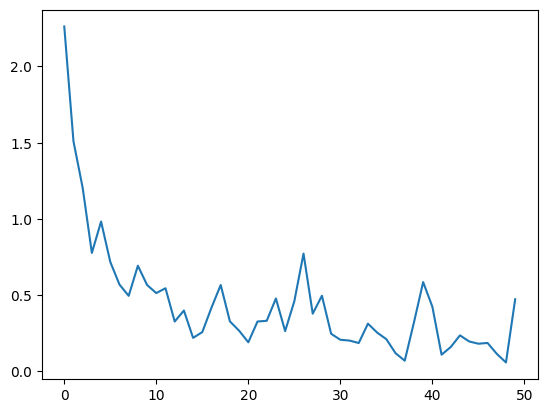

In [18]:
_ = plt.plot(history['loss'])

In [19]:
from sklearn.metrics import accuracy_score

_ = model.eval()

acc_vals = []
for batch_idx, (images, labels) in enumerate(test_loader):
  outputs = model(images)
  labels_pred = outputs.max(dim=1).indices
  acc_vals.append(accuracy_score(labels, labels_pred))

np.mean(acc_vals)

np.float64(0.9434904153354633)

In [20]:
# classes: CAT(0), DOG(1), COW(2)

outputs = torch.tensor([  # last layer's outputs for "5" samples
    [4, 1.2, 2],  # predicted class is 0
    [0, 2, 1.9],  # predicted class is 1
    [1, 0.5, 0.2],  # predicted class is 0
    [2, 6.2, 0.8],  # predicted class is 1
    [0.4, 6, 10],  # predicted class is 2
])

y_true = [0, 1, 0, 1, 2]
y_pred = torch.max(outputs, dim=1).indices.tolist()

accuracy_score(y_true, y_pred)

1.0